In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/14
    print("準備完了！このまま下のセルを実行できます。")

# 14.1-14.3 バギングと AdaBoost (Bagging & AdaBoost)

本ノートブックでは、複数の予測器を組み合わせて単一モデルよりも汎化性能を向上させるアンサンブル学習の基本、**バギング (Bootstrap Aggregating / Committees)** と **AdaBoost (Adaptive Boosting)** を学びます。

## 14.1 ベイズモデル平均化 (Bayesian Model Averaging)

アンサンブル学習の考え方を確率的な枠組みで捉える基礎として、ベイズモデル平均化があります。異なるモデル（あるいは仮説）の集合 $h$ が与えられたとき、予測分布は個々のモデルの予測分布を周辺化することによって得られます。
データ集合 $\mathbf{X}, \mathbf{t}$ が与えられたときの新しい入力 $\mathbf{x}$ に対する予測分布は次のように表されます：
$$ p(t|\mathbf{x},\mathbf{X},\mathbf{t}) = \sum_{h} p(t|\mathbf{x},h)p(h|\mathbf{X},\mathbf{t}) $$
ここで、$p(t|\mathbf{x},h)$ は特定の仮説 $h$ の下での予測分布、$p(h|\mathbf{X},\mathbf{t})$ はその仮説に対する事後確率です。これは、すべての可能なモデルによる予測を、それぞれの事後確率で重み付けして平均化していると解釈できます。ベイズモデル平均化は、モデルの不確実性を自然に扱う枠組みを提供します。

## 14.2 コミッティ (Committees)

実際には、ベイズモデル平均化を厳密に計算することは困難です。そこで、多数のモデルを構築し、それらの予測を単純に平均化する手法が広く用いられます。これを**コミッティモデル (Committee Models)** と呼びます。
コミッティは、個々のモデルの誤差の相殺を利用して全体としての予測誤差を低減させることを目的とします。続くセクションで、その分散低減のメカニズムを数学的に詳しく見ていきます。

## 14.2 コミッティモデルとバギングの分散低減定理 (PRML 式 14.10)

連続変数を予測する回帰問題を考えます。$M$ 個のモデルの予測値を $y_m(\mathbf{x})$ とし、真の関数を $h(\mathbf{x})$ とします。各モデルの誤差を $\epsilon_m(\mathbf{x}) = y_m(\mathbf{x}) - h(\mathbf{x})$ と定義します。
真の関数は平均ゼロのノイズを伴って観測されると仮定するため、誤差の期待値はゼロ $\mathbb{E}[\epsilon_m(\mathbf{x})] = 0$ となります。

個別のモデルの二乗誤差の平均（期待値）は以下のようになります：
$$ E_{\mathrm{AV}} = \frac{1}{M} \sum_{m=1}^M \mathbb{E}[\epsilon_m(\mathbf{x})^2] $$

これらを平均化したコミッティモデル $y_{\mathrm{COM}}(\mathbf{x}) = \frac{1}{M} \sum_{m=1}^M y_m(\mathbf{x})$ を考えます。その誤差は $\frac{1}{M} \sum_{m=1}^M \epsilon_m(\mathbf{x})$ であり、コミッティの期待二乗誤差は次のように分解できます：
$$ \begin{aligned} E_{\mathrm{COM}} &= \mathbb{E}\left[ \left( \frac{1}{M} \sum_{m=1}^M \epsilon_m(\mathbf{x}) \right)^2 \right] \\ &= \frac{1}{M^2} \sum_{m=1}^M \mathbb{E}[\epsilon_m(\mathbf{x})^2] + \frac{1}{M^2} \sum_{m \neq l} \mathbb{E}[\epsilon_m(\mathbf{x}) \epsilon_l(\mathbf{x})] \end{aligned} $$

ここで、極端な仮定として**各モデルの誤差が完全に無相関**であるとします。つまり $m \neq l$ に対して $\mathbb{E}[\epsilon_m(\mathbf{x}) \epsilon_l(\mathbf{x})] = 0$ が成り立つ場合、第2項は消滅し、以下の重要な関係が得られます：
$$ E_{\mathrm{COM}} = \frac{1}{M^2} \sum_{m=1}^M \mathbb{E}[\epsilon_m(\mathbf{x})^2] = \frac{1}{M} E_{\mathrm{AV}} $$
これは、完全に無相関な誤差を持つ $M$ 個のモデルを平均化すると、期待二乗誤差が $1/M$ に減少することを示しています（**分散低減定理**）。

### イェンゼンの不等式による保証

誤差が完全に無相関であるという仮定は現実的ではありませんが、少なくともコミッティモデルが単一のモデルよりも悪くなることはないことが**イェンゼンの不等式 (Jensen's inequality)** によって保証されます。
凸関数 $f$ に対して $f(\mathbb{E}[y]) \le \mathbb{E}[f(y)]$ が成り立ちます。今回、$f(y) = y^2$ （凸関数）と考えると：
$$ \left( \frac{1}{M} \sum_{m=1}^M y_m(\mathbf{x}) - h(\mathbf{x}) \right)^2 \le \frac{1}{M} \sum_{m=1}^M \left( y_m(\mathbf{x}) - h(\mathbf{x}) \right)^2 $$
この両辺の期待値を取ることで、常に $E_{\mathrm{COM}} \le E_{\mathrm{AV}}$ が成り立つことが証明されます。

### バギング (Bootstrap Aggregating)

実際には、単一の訓練データセットから独立なモデルを作ることはできません。そこで**バギング (Bagging)** が登場します。元のデータセット $\mathcal{D}$ から復元抽出によって同じサイズのデータセットを $M$ 個作成（ブートストラップ・サンプリング）し、それぞれのデータセットでモデルを学習させます。これにより、擬似的に独立なモデルを複数構築し、コミッティ平均による分散低減メカニズムを有効に働かせることができます。

Plot saved to: result/fig14_bagging_variance_reduction.png


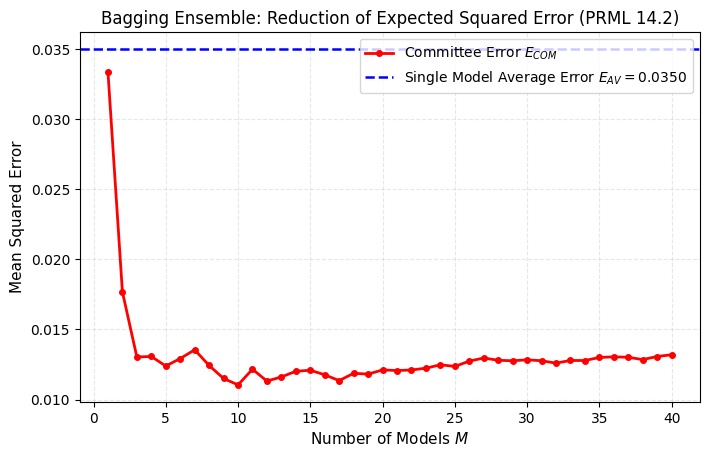

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from common.plot_utils import save_plot, setup_style
setup_style()

# 真の関数とノイズ付きデータ
np.random.seed(42)
N_train = 80
x_train = np.sort(np.random.uniform(0, 1, N_train))
y_true = np.sin(2 * np.pi * x_train)
y_train = y_true + np.random.normal(0, 0.25, N_train)

# テストデータ
x_test = np.linspace(0, 1, 200)
y_test_true = np.sin(2 * np.pi * x_test)

# M = 1 から 50 までのコミッティ (バギング) の構築
M_max = 40
committee_preds = []
indiv_errors = []

for m in range(M_max):
    # ブートストラップ・リサンプリング
    boot_idx = np.random.choice(N_train, N_train, replace=True)
    tree = DecisionTreeRegressor(max_depth=4, random_state=m)
    tree.fit(x_train[boot_idx, np.newaxis], y_train[boot_idx])
    pred = tree.predict(x_test[:, np.newaxis])
    committee_preds.append(pred)
    indiv_errors.append(np.mean((pred - y_test_true)**2))

committee_preds = np.array(committee_preds) # (M, 200)

# M 個の平均予測の誤差推移
com_errors = []
for m in range(1, M_max + 1):
    ens_pred = np.mean(committee_preds[:m], axis=0)
    com_errors.append(np.mean((ens_pred - y_test_true)**2))

E_AV = np.mean(indiv_errors)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(range(1, M_max + 1), com_errors, 'r-o', lw=2, markersize=4, label='Committee Error $E_{COM}$')
ax.axhline(E_AV, color='b', linestyle='--', lw=1.8, label=f'Single Model Average Error $E_{{AV}} = {E_AV:.4f}$')
ax.set_title('Bagging Ensemble: Reduction of Expected Squared Error (PRML 14.2)', fontsize=12)
ax.set_xlabel('Number of Models $M$', fontsize=11); ax.set_ylabel('Mean Squared Error', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig14_bagging_variance_reduction.png')
plt.show()

## 14.3 AdaBoost アルゴリズムの指数損失からの導出 (PRML 14.3.1)

AdaBoost は、直前の弱分類器が誤分類したデータ点の重みを指数関数的に増大させ、次の学習を誘導するアルゴリズムですが、これは**指数損失関数 (Exponential Loss) の逐次最適化**として厳密に導出することができます。

目標変数 $t_n \in \{-1, 1\}$ に対して、弱分類器 $y_m(\mathbf{x}_n) \in \{-1, 1\}$ とその結合係数 $\alpha_m$ を用いた複合分類器のモデルを考えます：
$$ f_M(\mathbf{x}) = \sum_{m=1}^M \alpha_m y_m(\mathbf{x}) $$
全体に対する指数損失関数 $E$ は、マージン $t_n f_M(\mathbf{x}_n)$ を用いて次のように定義されます：
$$ E = \sum_{n=1}^N \exp\left( -t_n f_M(\mathbf{x}_n) \right) = \sum_{n=1}^N \exp\left( -t_n \sum_{m=1}^M \alpha_m y_m(\mathbf{x}_n) \right) $$

### 逐次最適化 (Sequential Optimization)

$m-1$ 個の弱分類器がすでに学習済みで固定されていると仮定し、新しい弱分類器 $y_m$ とその重み $\alpha_m$ を最適化します。
損失関数を $m-1$ までの項と $m$ 番目の項に分離します：
$$ E = \sum_{n=1}^N w_n^{(m)} \exp\left( -t_n \alpha_m y_m(\mathbf{x}_n) \right) $$
ここで、$w_n^{(m)} = \exp\left( -t_n \sum_{l=1}^{m-1} \alpha_l y_l(\mathbf{x}_n) \right)$ はデータ点 $n$ の現在の重みであり、$y_m(\mathbf{x}_n)$ や $\alpha_m$ には依存しない定数とみなせます。

正しく分類された点（$y_m(\mathbf{x}_n) = t_n$）と誤分類された点（$y_m(\mathbf{x}_n) \neq t_n$）で和を分割します：
$$ \begin{aligned} E &= e^{-\alpha_m} \sum_{y_m(\mathbf{x}_n) = t_n} w_n^{(m)} + e^{\alpha_m} \sum_{y_m(\mathbf{x}_n) \neq t_n} w_n^{(m)} \\ &= e^{-\alpha_m} \sum_{n=1}^N w_n^{(m)} + \left( e^{\alpha_m} - e^{-\alpha_m} \right) \sum_{y_m(\mathbf{x}_n) \neq t_n} w_n^{(m)} \end{aligned} $$

#### 弱分類器 $y_m$ の最適化
$\alpha_m > 0$ であると仮定すると、第2項の係数 $(e^{\alpha_m} - e^{-\alpha_m})$ は正になります。したがって、$E$ を最小化する弱分類器 $y_m(\mathbf{x})$ は、重み付けされた誤分類数を最小化するものとなります。
これが AdaBoost において「データ点に重みをつけて弱分類器を学習する」という手順の理論的根拠です。

#### 係数 $\alpha_m$ の最適化
次に、$E$ を $\alpha_m$ について微分してゼロと置きます。重み付き誤分類率 $\epsilon_m$ を以下のように定義します：
$$ \epsilon_m = \frac{\sum_{y_m(\mathbf{x}_n) \neq t_n} w_n^{(m)}}{\sum_{n=1}^N w_n^{(m)}} $$
これを用いると、最適化の条件式は：
$$ \frac{\partial E}{\partial \alpha_m} = -e^{-\alpha_m} (1 - \epsilon_m) \sum_{n=1}^N w_n^{(m)} + e^{\alpha_m} \epsilon_m \sum_{n=1}^N w_n^{(m)} = 0 $$
これを $\alpha_m$ について解くと、AdaBoost の特徴的な係数の式が得られます：
$$ \alpha_m = \frac{1}{2} \ln \left( \frac{1 - \epsilon_m}{\epsilon_m} \right) $$

#### 重みの更新
$m$ 番目の反復が終了した後の新しい重み $w_n^{(m+1)}$ は、定義より次のように更新されます：
$$ w_n^{(m+1)} = w_n^{(m)} \exp\left( -\alpha_m t_n y_m(\mathbf{x}_n) \right) $$
正解したデータ点は $e^{-\alpha_m}$ 倍、誤分類されたデータ点は $e^{\alpha_m}$ 倍されます。
この結果、1反復ごとの損失関数（重みの総和）は、元の損失の $2\sqrt{\epsilon_m(1-\epsilon_m)}$ 倍に減少していくことが示されます。

Plot saved to: result/fig14_2_adaboost_iterations.png


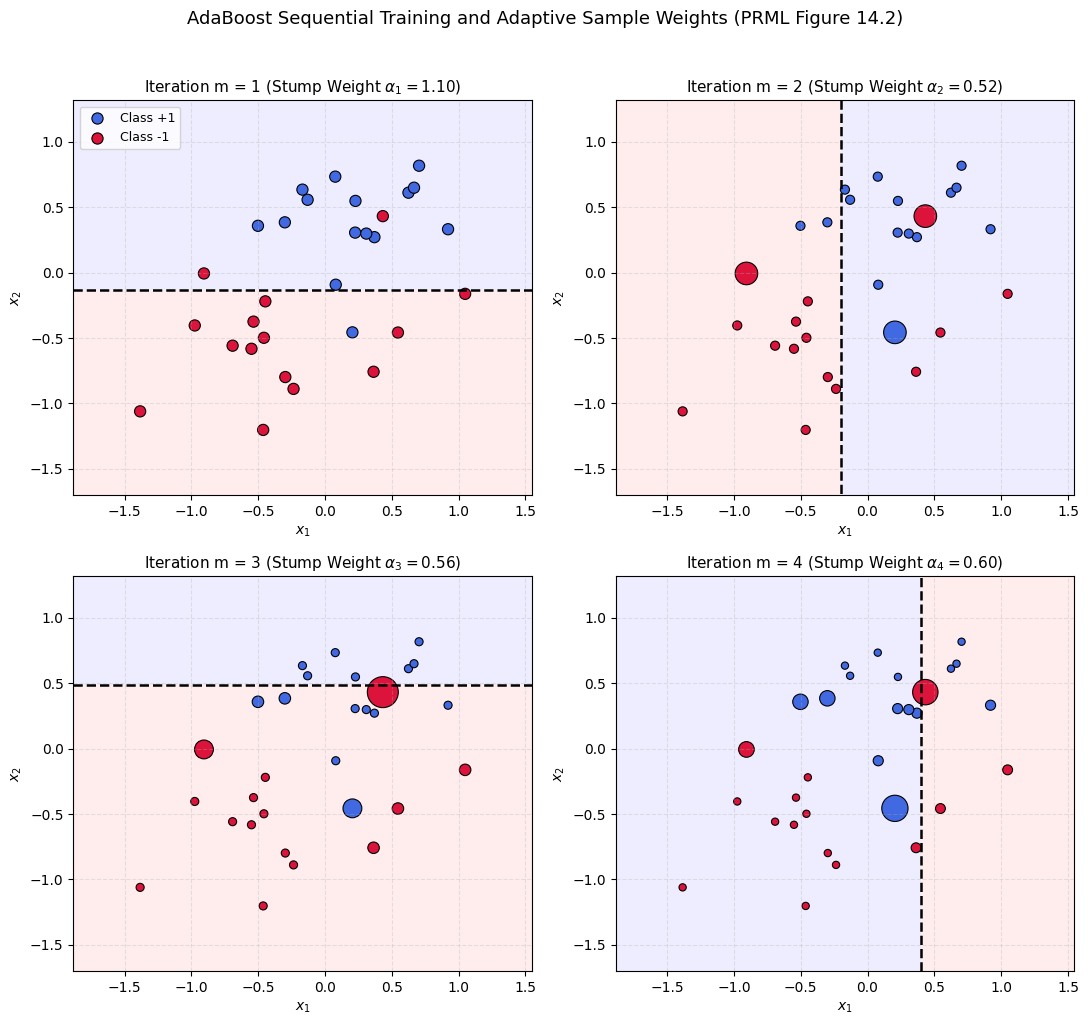

In [2]:
from common.ensemble_utils import AdaBoostClassifier

# 非線形な2クラス2次元トイデータセット (PRML Figure 14.2 準拠)
np.random.seed(14)
N_pts = 30
X_pos = np.random.randn(N_pts // 2, 2) * 0.4 + np.array([0.3, 0.3])
X_neg = np.random.randn(N_pts // 2, 2) * 0.5 + np.array([-0.3, -0.3])
X_ada = np.vstack([X_pos, X_neg])
y_ada = np.array([1]*(N_pts // 2) + [-1]*(N_pts // 2))

# 4反復の AdaBoost
ada = AdaBoostClassifier(n_estimators=4).fit(X_ada, y_ada)

# グリッドの作成
x_min, x_max = X_ada[:, 0].min() - 0.5, X_ada[:, 0].max() + 0.5
y_min, y_max = X_ada[:, 1].min() - 0.5, X_ada[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# PRML Figure 14.2 のプロット (イテレーション 1, 2, 3 と複合境界)
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.ravel()

for m in range(4):
    ax = axes[m]
    w = ada.weights_history[m] # 現在のイテレーションでのデータ点重み
    # 点の大きさを重みに比例させる
    point_sizes = (w / np.mean(w)) * 50.0 + 15.0
    
    # 弱分類器の決定境界
    stump = ada.models[m]
    pred_grid = stump.predict(grid_points).reshape(xx.shape)
    
    ax.contourf(xx, yy, pred_grid, levels=[-1.5, 0, 1.5], colors=['#ffcccc', '#ccccff'], alpha=0.35)
    ax.contour(xx, yy, pred_grid, levels=[0], colors='k', linestyles='--', linewidths=1.8)
    
    # データ点のプロット
    ax.scatter(X_ada[y_ada == 1, 0], X_ada[y_ada == 1, 1], color='royalblue',
               s=point_sizes[y_ada == 1], edgecolors='k', lw=0.8, label='Class +1')
    ax.scatter(X_ada[y_ada == -1, 0], X_ada[y_ada == -1, 1], color='crimson',
               s=point_sizes[y_ada == -1], edgecolors='k', lw=0.8, label='Class -1')
    
    ax.set_title(f'Iteration m = {m+1} (Stump Weight $\\alpha_{m+1} = {ada.alphas[m]:.2f}$)', fontsize=11)
    ax.set_xlabel('$x_1$', fontsize=10); ax.set_ylabel('$x_2$', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)
    if m == 0:
        ax.legend(loc='upper left', fontsize=9)

plt.suptitle('AdaBoost Sequential Training and Adaptive Sample Weights (PRML Figure 14.2)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig14_2_adaboost_iterations.png')
plt.show()

## 14.3.2 分類における損失関数の比較 (PRML Figure 14.3)

真のクラス $t \in \{-1, 1\}$ と判別関数 $f(\mathbf{x})$ の積である**マージン** $z = t f(\mathbf{x})$ を用いて、様々な損失関数（サロゲート損失）の振る舞いを比較します。マージン $z > 0$ は正しい分類、$z < 0$ は誤分類を意味します。

- **誤分類損失 (0-1 Loss)**: $\mathbb{I}(z < 0)$。理想的ですが不連続であり勾配ベースの最適化が不可能です。
- **指数損失 (Exponential Loss)**: $E_{\mathrm{EXP}}(z) = \exp(-z)$。AdaBoost が最小化する損失関数です。
- **ロジスティック損失 (Logistic Loss / Cross-Entropy)**: $E_{\mathrm{LOG}}(z) = \frac{1}{\ln 2} \ln(1 + \exp(-z))$。ロジスティック回帰で用いられます。
- **二乗誤差損失 (Squared Loss)**: $E_{\mathrm{SQR}}(z) = (1 - z)^2$。

### 損失関数の堅牢性 (Robustness)

**指数損失の脆弱性：**
指数損失は $z \ll 0$（つまり、大きな自信を持って誤分類される外れ値）に対して、ペナルティが指数関数的に増大します。勾配が有界ではない（$-\exp(-z)$）ため、データセット内に外れ値やノイズが存在する場合、アルゴリズムがその外れ値を正解しようと過剰に適合してしまい、非常に脆弱になります。

**ロジスティック損失の堅牢性：**
一方、ロジスティック損失は $z \ll 0$ に対して線形に増加し、勾配が一定値に飽和します。これにより、外れ値がモデルのパラメータ更新に与える影響が制限され、AdaBoost に比べて外れ値に対して堅牢（ロバスト）になります。二乗誤差は $z \gg 0$（正解だが自信過剰）に対してもペナルティを課すため、分類には不適切です。

### 漸近的真の最小化関数 (Population Minimizer)

データ数が無限大にある場合の期待損失 $\mathbb{E}_{t|\mathbf{x}}[L(t, f(\mathbf{x}))]$ を最小化する最適な関数 $f^*(\mathbf{x})$ を考えます。
指数損失の場合、変分法を用いると次のように求まります：
$$ f^*(\mathbf{x}) = \frac{1}{2} \ln \frac{p(t=1|\mathbf{x})}{p(t=-1|\mathbf{x})} $$
これはロジスティック回帰（交差エントロピー損失）の真の最小化関数と完全に同一（定数倍を除く）の対数オッズ（log-odds）となります。つまり、AdaBoost とロジスティック回帰は、異なる損失関数を出発点としながらも、無限データの下では同じ条件付き確率モデルを目指して最適化を行っているという深い関係があります。

Plot saved to: result/fig14_3_error_functions_comparison.png


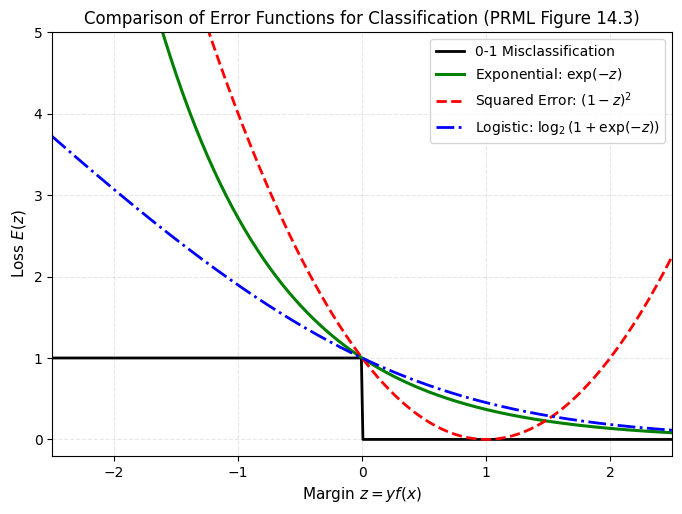

In [3]:
# マージン z のグリッド
z = np.linspace(-2.5, 2.5, 400)

loss_zero_one = np.where(z < 0, 1.0, 0.0)
loss_exp = np.exp(-z)
loss_sqr = (1.0 - z)**2
loss_log = np.log2(1.0 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(z, loss_zero_one, 'k-', lw=2.0, label='0-1 Misclassification')
ax.plot(z, loss_exp, 'g-', lw=2.2, label=r'Exponential: $\exp(-z)$')
ax.plot(z, loss_sqr, 'r--', lw=2.0, label=r'Squared Error: $(1-z)^2$')
ax.plot(z, loss_log, 'b-.', lw=2.0, label=r'Logistic: $\log_2(1 + \exp(-z))$')

ax.set_ylim(-0.2, 5.0)
ax.set_xlim(-2.5, 2.5)
ax.set_title('Comparison of Error Functions for Classification (PRML Figure 14.3)', fontsize=12)
ax.set_xlabel('Margin $z = y f(x)$', fontsize=11); ax.set_ylabel('Loss $E(z)$', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig14_3_error_functions_comparison.png')
plt.show()